# Spanish CEFR Classification with BERTIN

This notebook fine-tunes a strong Spanish encoder on a CEFR readability dataset, checks the holdout metrics, shows a confusion matrix, and prepares the model for upload to the Hub.

## System setup

In [1]:
!pip -q install transformers datasets accelerate evaluate scikit-learn huggingface_hub

## Imports and configuration

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)

In [3]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Dataset

A Spanish CEFR dataset with 31k examples from Hugging Face and a holdout split for validation and test.

In [4]:
dataset = load_dataset("UniversalCEFR/caes_es")

df = dataset["train"].to_pandas()

label_list = ["A1", "A2", "B1", "B2", "C1", "C2"]
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

df = df[df["cefr_level"].isin(label_list)].copy()
df["label"] = df["cefr_level"].map(label2id)

df = df.rename(columns={"essay": "text"})
df = df[["text", "label"]].dropna().reset_index(drop=True)

label_names = label_list

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=seed,
    stratify=df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=seed,
    stratify=temp_df["label"],
)

len(train_df), len(val_df), len(test_df), label_names

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


(21804, 4672, 4673, ['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

## A few examples

In [5]:
train_df.head()

,text,label
3203,Querido Ahmed . ¿ Qué tal ? Antes de nada quie...,2
18875,"Estimado Mr. Batarse , Espera que todo es bien...",1
4473,¡ Hola chicos ! Escribo este correo para conta...,1
12653,"Estimados nuevos compañeros de trabajo , Me ll...",0
13319,"¿ Ola ! Estás Bien ? Yo soy Antonio , tengo 49...",0


## Text length distribution among classes

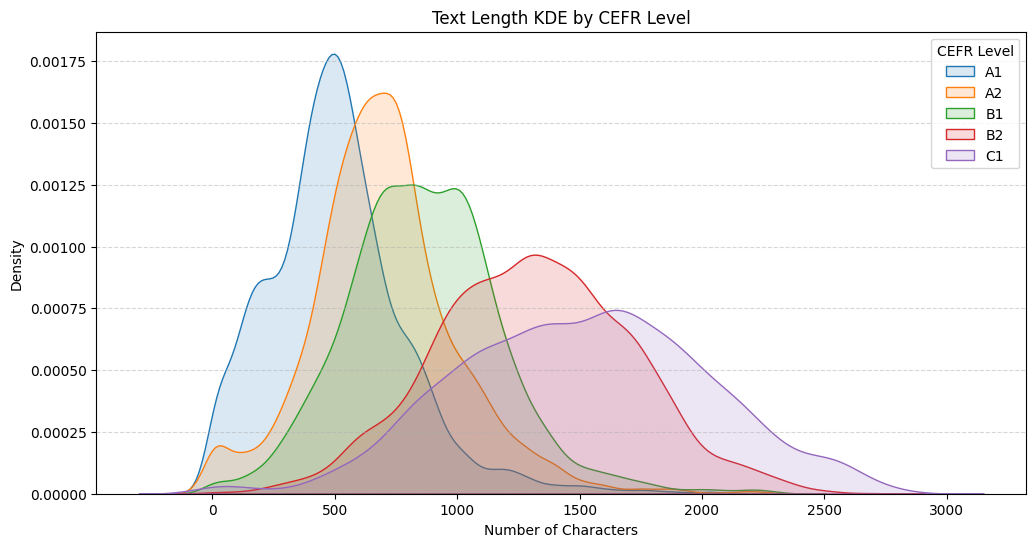

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df["text_len"] = df["text"].str.len()

plt.figure(figsize=(12, 6))
for label in label_list:
    subset = df[df["label"] == label2id[label]]
    sns.kdeplot(subset["text_len"], label=label, fill=True, alpha=0.17)

plt.title("Text Length KDE by CEFR Level")
plt.xlabel("Number of Characters")
plt.ylabel("Density")
plt.legend(title="CEFR Level")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


## Model

BERTIN is a Spanish RoBERTa-base model trained from scratch on Spanish mC4.

In [7]:
model_name = "bertin-project/bertin-roberta-base-spanish"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

max_length = 512
repo_id = f"pymlex/roberta-spanish-cefr"

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: bertin-project/bertin-roberta-base-spanish
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Torch-like datasets.

In [8]:
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=max_length)

train_ds = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True)).map(tokenize_batch, batched=True)
val_ds = Dataset.from_pandas(val_df[["text", "label"]].reset_index(drop=True)).map(tokenize_batch, batched=True)
test_ds = Dataset.from_pandas(test_df[["text", "label"]].reset_index(drop=True)).map(tokenize_batch, batched=True)

cols = ["input_ids", "attention_mask", "label"]
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

Map:   0%|          | 0/21804 [00:00<?, ? examples/s]

Map:   0%|          | 0/4672 [00:00<?, ? examples/s]

Map:   0%|          | 0/4673 [00:00<?, ? examples/s]

Base metrics.

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }

## Training

Such settings suit T4 15 GB VRAM.

In [10]:
args = TrainingArguments(
    output_dir="./bertin_cefr",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=4,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=100,
    num_train_epochs=5,
    weight_decay=0.01,
    save_strategy="epoch",
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=1,
    hub_model_id=repo_id,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)


In [11]:
train_out = trainer.train()
train_out

Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
100,0.566022,0.098864,0.978382,0.982360,0.978491,0.980367
200,0.205725,0.059238,0.986301,0.987747,0.986834,0.987265
300,0.133694,0.055091,0.988870,0.990312,0.989150,0.989711
400,0.095762,0.052623,0.989084,0.990369,0.989207,0.989768


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=430, training_loss=0.6660554780516513, metrics={'train_runtime': 2416.4359, 'train_samples_per_second': 45.116, 'train_steps_per_second': 0.178, 'total_flos': 2.868539743678464e+16, 'train_loss': 0.6660554780516513, 'epoch': 5.0})

In [12]:
val_metrics = trainer.evaluate(val_ds)
test_metrics = trainer.evaluate(test_ds)

pd.DataFrame([
    {"split": "val", **{k: float(v) for k, v in val_metrics.items() if k.startswith("eval_")}},
    {"split": "test", **{k: float(v) for k, v in test_metrics.items() if k.startswith("eval_")}},
])

,split,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,val,0.052044,0.989084,0.990369,0.989207,0.989768,32.4421,144.010,2.250
1,test,0.058439,0.988230,0.989575,0.989209,0.989375,32.2773,144.777,2.293


## Confusion matrix

In [13]:
pred = trainer.predict(test_ds)
y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=-1)

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))))

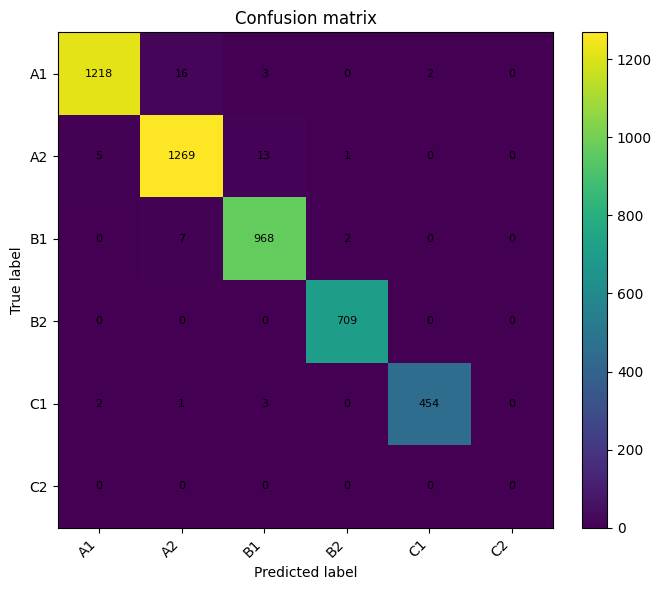

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation="nearest")
ax.set_title("Confusion matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_yticklabels(label_names)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## Hub upload

In [15]:
from huggingface_hub import login

login(token='YOUR_TOKEN')
trainer.push_to_hub(commit_message="Spanish CEFR fine-tuning")
print(repo_id)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...in_cefr/model.safetensors:   0%|          |  580kB /  499MB            

  ...in_cefr/training_args.bin:   2%|1         |  99.0B / 5.20kB            

pymlex/roberta-spanish-cefr


## Inference

In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_id = "pymlex/roberta-spanish-cefr"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSequenceClassification.from_pretrained(model_id)
model.eval()

def predict_cefr(text, top_k=3):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    )
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)[0]

    k = min(top_k, probs.numel())
    values, indices = torch.topk(probs, k=k)

    return [
        {
            "label": model.config.id2label[i.item()],
            "score": float(v.item()),
        }
        for i, v in zip(indices, values)
    ]

text = "Estimados señores, les escribo para solicitar información sobre el curso."
print(predict_cefr(text, top_k=3))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/377 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'A1', 'score': 0.22886891663074493}, {'label': 'B1', 'score': 0.19498008489608765}, {'label': 'A2', 'score': 0.19106613099575043}]
